#**Project Title: Titanic Survival Analysis**

#**Problem Statement**

Analyze passenger data to identify the key factors that influenced survival in the Titanic disaster.

#**Objective**

To explore and find patterns in survival based on demographics, class, age, fare, and family structure.

#**Domain**

Transportation / Maritime Disaster Analysis (Historical Data Analysis)

#**Features with Description**

**PassengerId** – Unique ID for each passenger

**Survived** – Survival status (0 = No, 1 = Yes)

**Pclass** – Passenger class (1 = High, 3 = Low)

**Name** – Passenger name

**Sex** – Gender of passenger

**Age** – Age of passenger

**SibSp** – Number of siblings/spouses aboard

**Parch** – Number of parents/children aboard

**Ticket** – Ticket number

**Fare** – Ticket fare paid

**Embarked** – Port of embarkation

**Family_size** – Total family members onboard

#**Data Reading, Cleaning and Pre-processing**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('https://github.com/rajespriya1-pixel/titanic-survival-analysis/raw/4c40518dc1a581ff3d64908977899e038345cd19/Titanic%20dataset.csv')

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#**Handling Null Values**

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Handling Null values by impute the mean value
df['Age']=df['Age'].fillna(df['Age'].mean())

In [ ]:
# Handling the Null values in cabin column (687 Null Values) by drop
df=df.drop('Cabin',axis=1)

In [ ]:
#Handling the Null values in Embarked column by impute the mode value
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

#**Validating Null Values**

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S


In [ ]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,89
SibSp,7
Parch,7
Ticket,681
Fare,248


# **Feature transformations**


**Checking Skewness**

In [ ]:
df.skew(numeric_only=True)

,0
PassengerId,0.000000
Survived,0.478523
Pclass,-0.630548
Age,0.434488
SibSp,3.695352
Parch,2.749117
Fare,4.787317


In [ ]:
cols=['SibSp','Parch','Fare']
df[cols]=np.log1p(df[cols])

**Validating Skewness**

In [ ]:
df[cols].skew()

,0
SibSp,1.661245
Parch,1.675439
Fare,0.394928


**Derived Fields**

In [ ]:
df['family_size']=df['SibSp']+df['Parch']+1

In [ ]:
bins=[0,12,20,40,60,100]
labels=['child','teen','adult','middle_age','Senior']
df['Age_group']=pd.cut(df['Age'],bins=bins,labels=labels)

#**EDA and Visualizations**

#**Age Distribution**

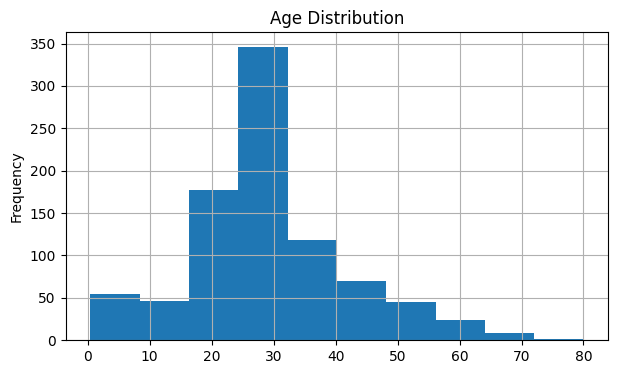

In [ ]:
plt.figure(figsize=(7,4))
df['Age'].plot(kind='hist',title='Age Distribution')
plt.grid(True)

**Interpretation**
Most passengers are young adults (20–35 age group)

Fewer children and elderly passengers

Distribution is right-skewed

#**Fare Distribution**

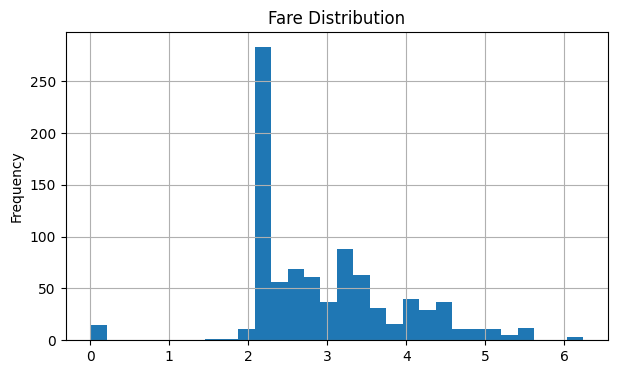

In [ ]:
plt.figure(figsize=(7,4))
df['Fare'].plot(kind='hist',bins=30,title='Fare Distribution')
plt.grid(True)

**Interpretation**

Strong right skew shows that most passengers paid low fares, few paid very high


#**Survived Vs Sex**

<Axes: title={'center': 'Survival Rate'}, xlabel='Sex'>

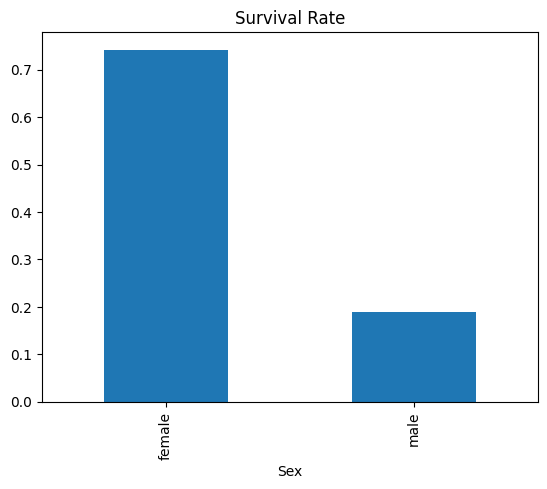

In [ ]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar',title='Survival Rate')

**Interpretation**

* Females survival rate is very high.Males survival rate is very low.

* This clearly shows that women had much higher chance of survival.

#**Survived Vs PClass**

<Axes: title={'center': 'Survival Rate by Passanger Class'}, xlabel='Pclass'>

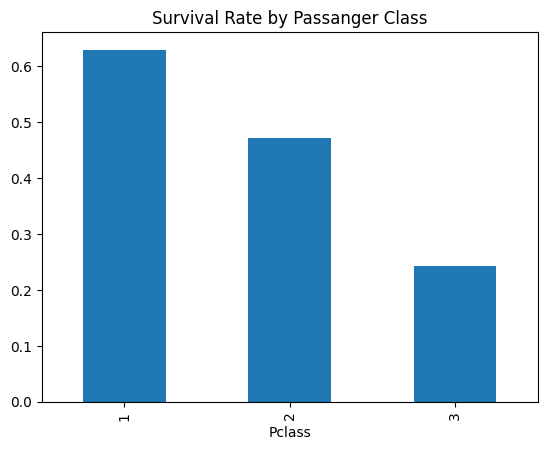

In [ ]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar',title='Survival Rate by Passanger Class')

**Interpretation**
* Survival rate is highest in Class 1, followed by Class 2, and lowest in Class 3.

* This suggests higher class (wealth) increased chances of survival.

#**Survived Vs Age Group**

/tmp/ipykernel_9090/1285393322.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_group')['Survived'].mean().plot(kind='bar',ax=ax[0],title='Survival Rate by Age Group')


<Axes: title={'center': 'Survival Count by Age Group'}, xlabel='Age_group'>

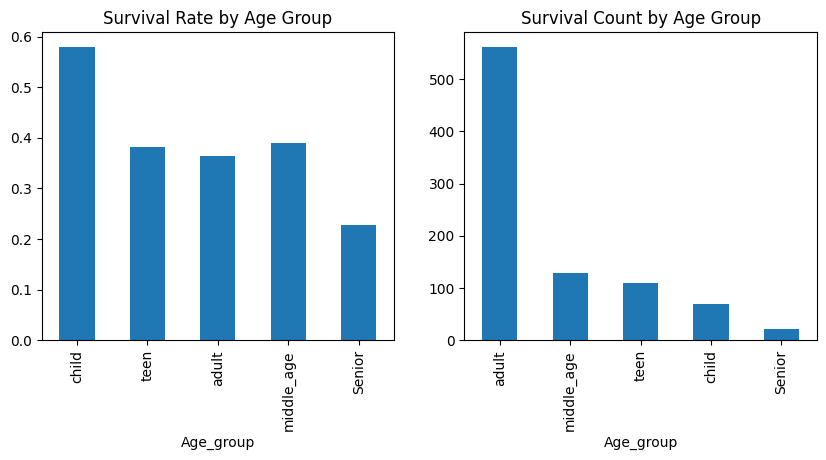

In [ ]:
fig,ax=plt.subplots(1,2, figsize=(10,4))

df.groupby('Age_group')['Survived'].mean().plot(kind='bar',ax=ax[0],title='Survival Rate by Age Group')

df['Age_group'].value_counts().plot(kind='bar',ax=ax[1],title='Survival Count by Age Group')


**Interpretation**

* Children had higher survival rate.
Teens, Adults, Middle age had moderate & similar survival rate.
Seniors had lowest survival rate.

* This clearly show that younger passangers had better survival chances.

#**Survived vs Family_size (alone vs family)**

In [ ]:
df['family_size'] = df['SibSp'].astype(int) + df['Parch'].astype(int) + 1

<Axes: title={'center': 'Survival Rate by Family Size'}, xlabel='family_size'>

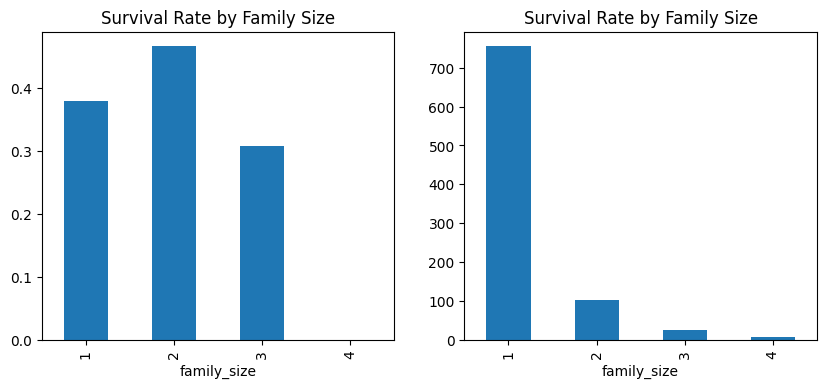

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(10,4))

df.groupby('family_size')['Survived'].mean().plot(kind='bar',ax=ax[0],title='Survival Rate by Family Size')

df['family_size'].value_counts().plot(kind='bar',ax=ax[1],title='Survival Rate by Family Size')


**Interpretation**
* Small family had higher survival rate

* Alone (1) had moderate survival rate


#**Sex + Pclass vs Survived**

<Axes: title={'center': 'Survival Rate by Gender and Passenger Class '}, xlabel='Sex'>

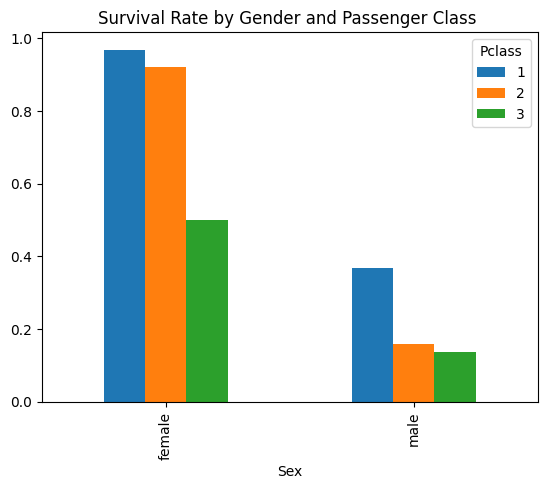

In [ ]:
df.groupby(['Sex','Pclass'])['Survived'].mean().unstack().plot(kind='bar',title='Survival Rate by Gender and Passenger Class ')

**Interpretation**
* Females had  high survival in all classes (especially Class 1)

* Males had low survival, worst in Class 3

* Class 1 had best survival overall

#**Summary**
The dataset was cleaned by handling missing values and transforming features. Exploratory Data Analysis was performed to understand survival patterns based on gender, class, age, fare, and family size.

#**Descriptive Analysis**
* Dataset: 891 rows, 12 columns

* Majority: young adults (20–35)

* Fare is highly right-skewed

* More male passengers than female

#**Diagnestic Analysis**
* Survival was higher among females than males

* And higher in Class 1 followed by Class 2 and Class 3

* Survival chance greater for children compared to adults and seniors, and better for small families than large families.

#**Predictive Analysis**

* Survival mainly depends on gender, passenger class (Wealth), age group, and family size, with females, higher-class passengers, younger individuals, and small families having better chances of survival.

#**Prescriptive Analysis**
* Priority evacuation for women and children led to higher survival rates

* Improve safety access for lower-class passengers



#**Conclusion**
Survival was strongly influenced by gender, with females having much higher survival than males.

Passenger class and fare show that wealthier individuals had better chances of survival.

Children had higher survival rates, while seniors had the lowest.

Passengers in small families had better survival compared to large families or those traveling alone.